# Artificial Neural Network (Multilayer Perceptron)
Now that we know what a single layer perceptron is, we can extend this discussion to multilayer perceptrons, or more commonly known as artificial neural networks. A single layer perceptron can solve simple problems where data is linearly separable into 'n' dimensions, where 'n' is the number of features in the dataset. However, in case of non-linearly separable data, the accuracy of single layer perceptrons decreases significantly. Multilayer perceptrons, on the other hand, can work efficiently with non-linearly separable data.

**Multilayer perceptrons, or more commonly referred to as artificial neural networks, are a combination of multiple neurons connected in the form of a network.** An artificial neural network has an input layer, one or more hidden layers, and an output layer. This is shown in the image below:

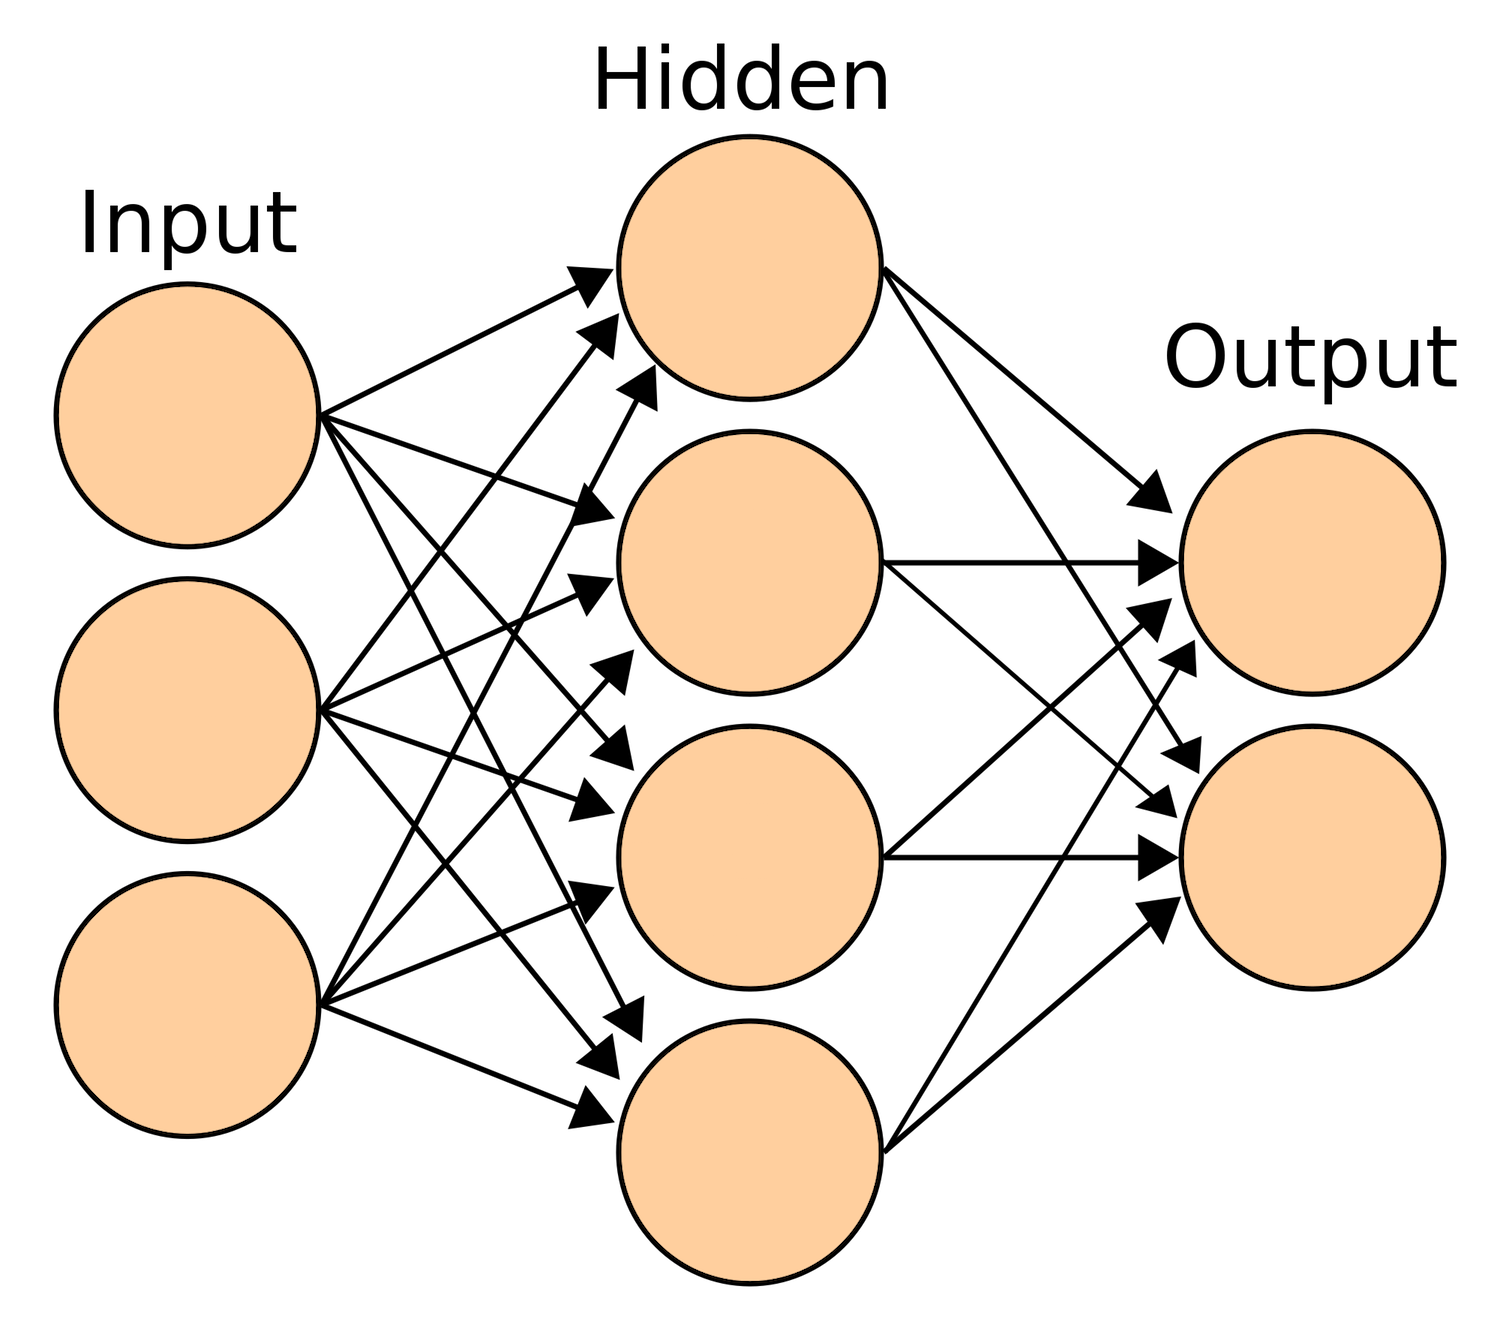

**A neural network executes in two phases: Feed-Forward and Back Propagation.**

#### Feed-Forward
Following are the steps performed during the feed-forward phase:

- The values received in the input layer are multiplied with the weights. A bias is added to the summation of the inputs and weights in order to avoid null values.
- Each neuron in the first hidden layer receives different values from the input layer depending upon the weights and bias. Neurons have an activation function that operates upon the value received from the input layer. The activation function can be of many types, like a step function, sigmoid function, relu function, or tanh function. As a rule of thumb, ReLU function is used in the hidden layer neurons and sigmoid function is used for the output layer neuron.
- The outputs from the first hidden layer neurons are multiplied with the weights of the second hidden layer; the results are summed together and passed to the neurons of the proceeding layers. This process continues until the outer layer is reached. The values calculated at the outer layer are the actual outputs of the algorithm.


The feed-forward phase consists of these three steps. However, the predicted output is not necessarily correct right away; it can be wrong, and we need to correct it. The purpose of a learning algorithm is to make predictions that are as accurate as possible. To improve these predicted results, a neural network will then go through a back propagation phase. During back propagation, the weights of different neurons are updated in a way that the difference between the desired and predicted output is as small as possible.

#### Back Propagation
Back propagation phase consists of the following steps:

- The error is calculated by quantifying the difference between the predicted output and the desired output. This difference is called "loss" and the function used to calculate the difference is called the "loss function". Loss functions can be of different types e.g. mean squared error or cross entropy functions. Remember, neural networks are supervised learning algorithms that need the desired outputs for a given set of inputs, which is what allows it to learn from the data.
- Once the error is calculated, the next step is to minimize that error. To do so, the partial derivative of the error function is calculated with respect to all the weights and biases. This is called gradient descent. The derivatives can be used to find the slope of the error function. If the slope is positive, the value of the weights can be reduced or if the slope is negative the value of weight can be increased. This reduces the overall error. The function that is used to reduce this error is called the optimization function.

**This one cycle of feed-forward and back propagation is called one "epoch".**

This process continues until a reasonable accuracy is achieved. There is no standard for reasonable accuracy, ideally you'd strive for 100% accuracy, but this is extremely difficult to achieve for any non-trivial dataset. In many cases 90%+ accuracy is considered acceptable, but it really depends on your use-case.

# Basic Deep Learning Project

The steps you will learn in this tutorial are as follows:

- Load Data
- Define Keras Model
- Compile Keras Model
- Fit Keras Model
- Evaluate Keras Model
- Tie It All Together
- Make Predictions



### 1. Load Data
The first step is to define the functions and classes you intend to use in this tutorial.

You will use the NumPy library to load your dataset and two classes from the Keras library to define your model.

The imports required are listed below.

In [2]:
!pip install tensorflow

  Obtaining dependency information for tensorflow from https://files.pythonhosted.org/packages/80/6f/57d36f6507e432d7fc1956b2e9e8530c5c2d2bfcd8821bcbfae271cd6688/tensorflow-2.14.0-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for tensorflow-intel==2.14.0 from https://files.pythonhosted.org/packages/ad/6e/1bfe367855dd87467564f7bf9fa14f3b17889988e79598bc37bf18f5ffb6/tensorflow_intel-2.14.0-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for absl-py>=1.0.0 from https://files.pythonhosted.org/packages/01/e4/dc0a1dcc4e74e08d7abedab278c795eef54a224363bb18f5692f416d834f/absl_py-2.0.0-py3-none-any.whl.metadata
  Obtaining dependency information for flatbuffers>=23.5.26 from https://files.pythonhosted.org/packages/6f/12/d5c79ee252793ffe845d58a913197bfa02ae9a0b5c9bc3dc4b58d477b9e7/flatbuffers-23.5.26-py2.py3-none-any.whl.metadata
     ---------------------------------------- 0.0/57.5 kB ? eta -:--:--
     ---------------------------------------- 57.5

DEPRECATION: textract 1.6.5 has a non-standard dependency specifier extract-msg<=0.29.*. pip 23.3 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of textract or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063


In [3]:
# first neural network with keras tutorial
from numpy import loadtxt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

There are eight input variables and one output variable (the last column). You will be learning a model to map rows of input variables (X) to an output variable (y), which is often summarized as y = f(X).

The variables can be summarized as follows:

Input Variables (X):

- Number of times pregnant
- Plasma glucose concentration at 2 hours in an oral glucose tolerance test
- Diastolic blood pressure (mm Hg)
- Triceps skin fold thickness (mm)
- 2-hour serum insulin (mu U/ml)
- Body mass index (weight in kg/(height in m)^2)
- Diabetes pedigree function
- Age (years)
- Output Variables (y):

Class variable (0 or 1)

Once the CSV file is loaded into memory, you can split the columns of data into input and output variables.

The data will be stored in a 2D array where the first dimension is rows and the second dimension is columns, e.g., [rows, columns].

You can split the array into two arrays by selecting subsets of columns using the standard NumPy slice operator or “:”. You can select the first eight columns from index 0 to index 7 via the slice 0:8. We can then select the output column (the 9th variable) via index 8.

In [4]:
# load the dataset
dataset = loadtxt('pima-indians-diabetes.csv', delimiter=',')


In [24]:
dataset

array([[  6.   , 148.   ,  72.   , ...,   0.627,  50.   ,   1.   ],
       [  1.   ,  85.   ,  66.   , ...,   0.351,  31.   ,   0.   ],
       [  8.   , 183.   ,  64.   , ...,   0.672,  32.   ,   1.   ],
       ...,
       [  5.   , 121.   ,  72.   , ...,   0.245,  30.   ,   0.   ],
       [  1.   , 126.   ,  60.   , ...,   0.349,  47.   ,   1.   ],
       [  1.   ,  93.   ,  70.   , ...,   0.315,  23.   ,   0.   ]])

In [5]:
# split into input (X) and output (y) variables
X = dataset[:,0:8]
y = dataset[:,8]

## Define Keras Model
Models in Keras are defined as a sequence of layers.

We create a Sequential model and add layers one at a time until we are happy with our network architectur**

The first thing to get right is to ensure the input layer has the correct number of input feat**es. This can be specified when creating the first layer with the input_shape argument and setting it to (8,) for presenting the eight input variables as a vecr.to nction.r.m.r.

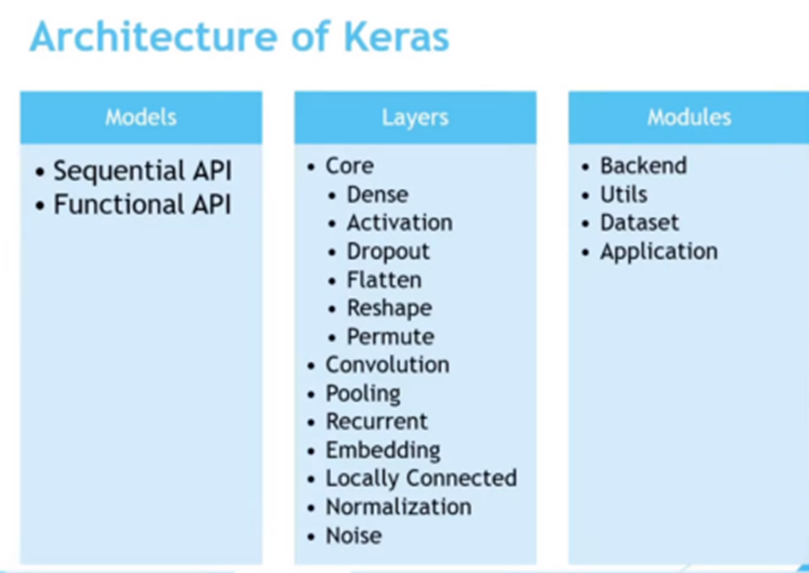

### SEQUENTIAL API

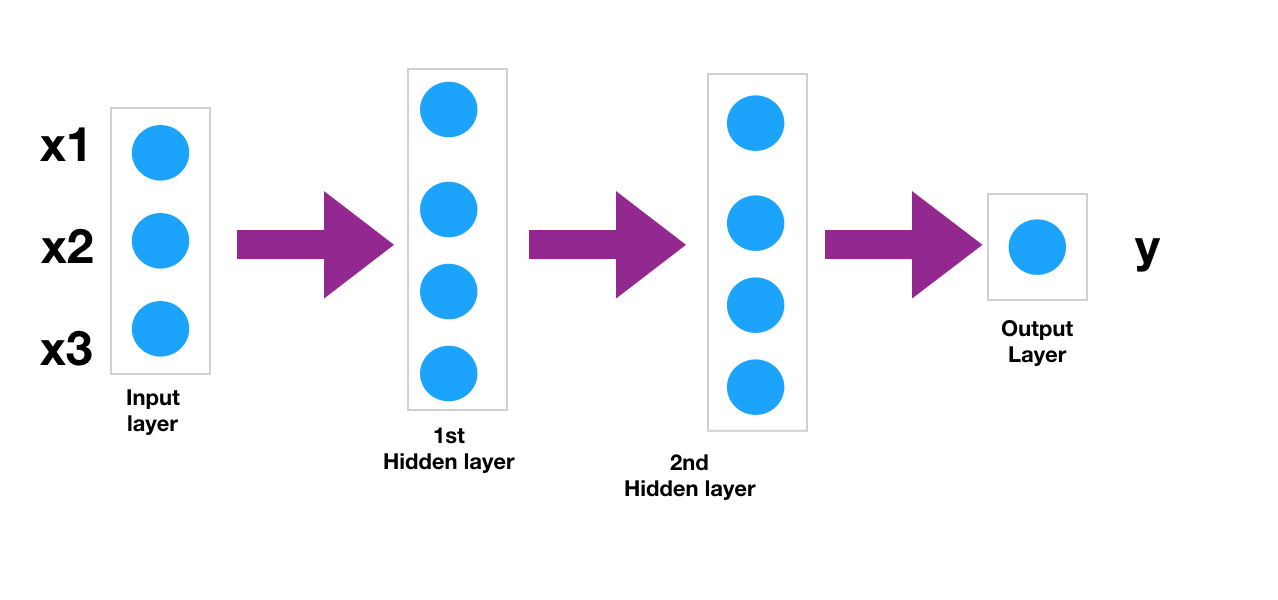

### FUNCTIONAL API

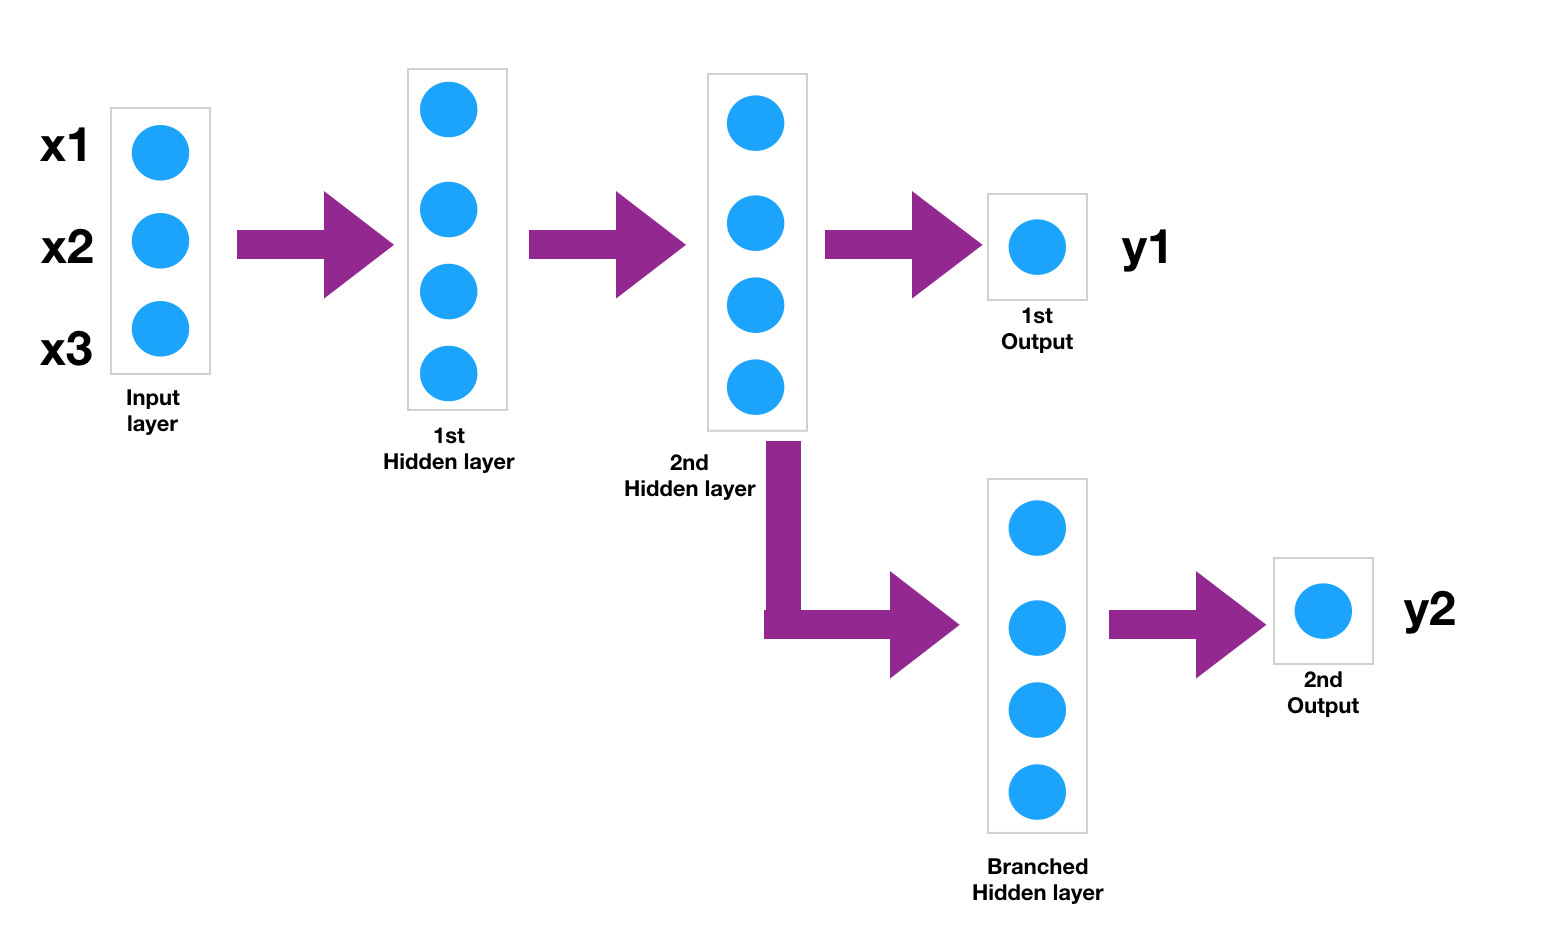

### How do we know the number of layers and their types?

This is a tricky question. There are heuristics that you can use, and often the best network structure is found through a process of trial and error experimentation (I explain more about this here). Generally, you need a network large enough to capture the structure of the proble

- **Fully connected layers are defined using the Dense class**. You can specify the number of neurons or nodes in the layer as the first argument and the activation function using the activation argument.

- Also, you will use the **rectified linear unit activation function** referred to as ReLU on the first two layers and the Sigmoid function in the output laye

It used to be the case that Sigmoid and Tanh activation functions were preferred for all layers. These days, better performance is achieved using the ReLU activation function. Using a sigmoid on the output layer ensures your network output is between 0 and 1 and is easy to map to either a probability of class 1 or snap to a hard classification of either class with a default threshold of 0.5.

You can piece it all together by adding each layer:
- The model expects rows of data with 8 variables (the input_shape=(8,) argument).
- The first hidden layer has 12 nodes and uses the relu activation function.
- The second hidden layer has 8 nodes and uses the relu activation function.
- The output layer has one node and uses the sigmoid activation function.


#### Keras provides a wide range of built-in layers, among them, the most commonly used layers are:

- **Dense layer**: It's a fully connected layer, it connects every neuron from the previous layer to every neuron in the current layer.

- **Convolutional layer**: They are commonly used in convolutional neural networks (CNNs) for image and video processing

- **Pooling layer**: They downsample the input data by summarizing local regions. Max pooling is a commonly used pooling layer that selects the maximum value within each region

- **Recurrent layer**: Recurrent layers, such as LSTM and GRU. They are designed for processing sequential data. They capture temporal dependencies by maintaining memory cells and incorporating gates to control information flow.

- **Embedding layer**: It learns the representation of words or tokens by mapping them to continuous, dense vectors, capturing semantic

In [6]:
...
# define the keras model
model = Sequential()
model.add(Dense(12, input_shape=(8,), activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In our neural network, we are using two hidden layers of 16 and 12 dimension.

**Sequential** specifies to keras that we are creating model sequentially and the output of each layer we add is input to the next layer we specify.

**model.add** is used to add a layer to our neural network. We need to specify as an argument what type of layer we want. The Dense is used to specify the fully connected layer.

#### What is an activation function?**

In a nutshell, **the activation function of a node defines the output of that node**.

The activation function (or transfer function) translates the input signals to output signals. It maps the output values on a range like 0 to 1 or -1 to 1. It’s an abstraction that represents the rate of action potential firing in the cell. It’s a number that represents the likelihood that the cell will fire. At it’s simplest, the function is binary: yes (the neuron fires) or no (the neuron doesn’t fire). The output can be either 0 or 1 (on/off or yes/no), or it can be anywhere in a range. If you were using a function that maps a range between 0 and 1 to determine the likelihood that an image is a cat, for example, an output of 0.9 would show a 90% probability that your image is, in fact, a cat.

- **Threshold function** This is a step function. **If the summed value of the input reaches a certain threshold the function passes on 0. If it’s equal to or more than zero, then it would pass on 1**. It’s a very rigid, straightforward, yes or no function.

- **Sigmoid function**: This function is **used in logistic regression**. Unlike the threshold function, **it’s a smooth, gradual progression from 0 to 1**. It’s very useful in the output layer and is heavily used for linear regression. (Linear regression is one of the most well-known algorithms in statistics and machine learning).

- **Hyperbolic Tangent Function** This function is very similar to the sigmoid function. Unlike the sigmoid function which goes from 0 to 1, **the value goes below zero, from -1 to 1**. Although this isn’t what happens in biology, this function gives **better results when it comes to training neural networks**. Neural networks sometimes get “stuck” during training with the sigmoid function. This happens when there’s a lot of strongly negative input that keeps the output near zero, which messes with the learning process.

- **Rectifier function** This might be the most popular activation function in the universe of neural networks. It’s the most efficient and biologically plausible. Even though it has a kink, it’s smooth and gradual after the kink at 0. This means, for example, that your output would be either “no” or a percentage of “yes.” This function doesn’t require normalization or other complicated calculations.



So let’s say, for example, your desired value is binary. You’re looking for a “yes” or a “no.” Which activation function do you want to use? From the above examples, you could use the threshold function, or you could go with the sigmoid activation function. The sigmoid function would be able to give you the probability of a yes.

## What is a Gradient?
### "A gradient measures how much the output of a function changes if you change the inputs a little bit." 

**A gradient simply measures the change in all weights with regard to the change in error**. You can also think of a gradient as the slope of a function. The higher the gradient, the steeper the slope and the faster a model can learn. But if the slope is zero, the model stops learning. 



# What is Activation Function?
Activation functions are functions used in a neural network to compute the weighted sum of inputs and biases, which is in turn **used to decide whether a neuron can be activated or not**. It manipulates the presented data and produces an output for the neural network that contains the parameters in the data. The activation functions are also referred to as **transfer functions** in some literature. These can either be **linear or nonlinear** depending on the function it represents and is **used to control the output of neural networks across different domains**.

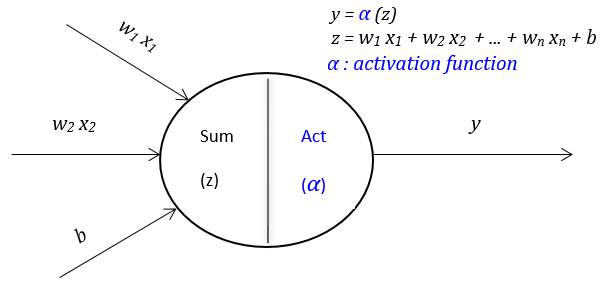












The need for these activation functions includes converting the linear input signals and models into non-linear output signals, which aids the learning of high order polynomials for deeper networks.

Most neural networks begin by computing the weighted sum of the inputs. Each node in the layer can have its own unique weighting. However, the activation function is the same across all nodes in the layer. They are typical of a fixed form whereas the weights are considered to be the learning parameters. 

# Types of Activation Functions
The different kinds of activation functions include:

## Linear Activation Functions
A linear function is also known as a straight-line function where the activation is proportional to the input i.e. the weighted sum from neurons. It has a simple function with the equation:

f(x) = ax + c

**The problem with this activation is that it cannot be defined in a specific range. Applying this function in all the nodes makes the activation function work like linear regression**. The final layer of the Neural Network will be working as a linear function of the first layer.

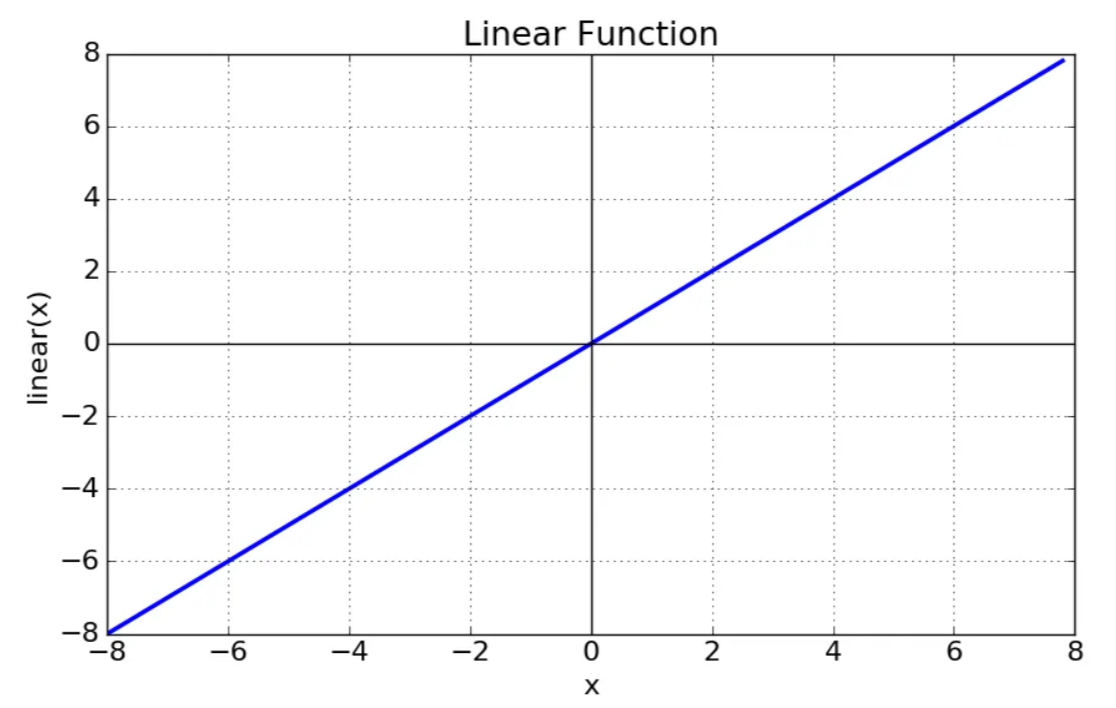

## Non-Linear Activation Functions
The non-linear functions are known to be the most used activation functions. It makes it easy for a neural network model to adapt with a variety of data and to differentiate between the outcomes.

These functions are mainly divided basis on their range or curves:

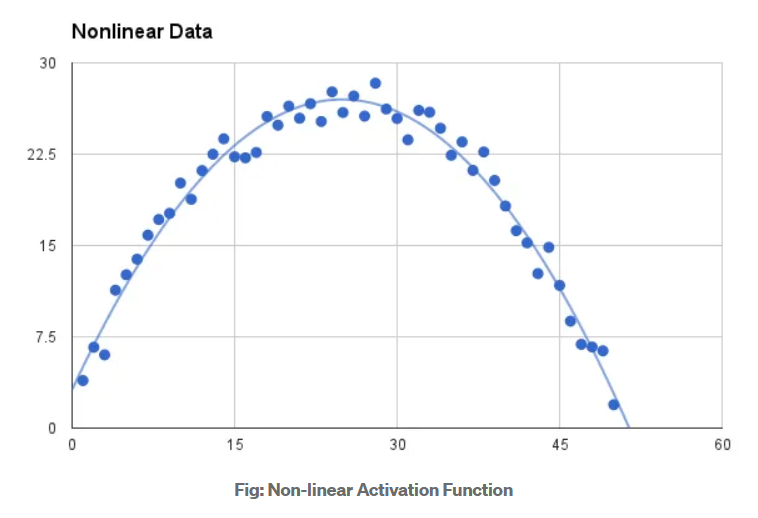

### a) Sigmoid Activation Functions
Sigmoid takes a real value as the input and outputs another value between 0 and 1. The sigmoid activation function translates the input ranged in (-∞,∞) to the range in (0,1)

C:\Users\Leena Ali\AppData\Local\Temp\ipykernel_36584\4152606823.py:18: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


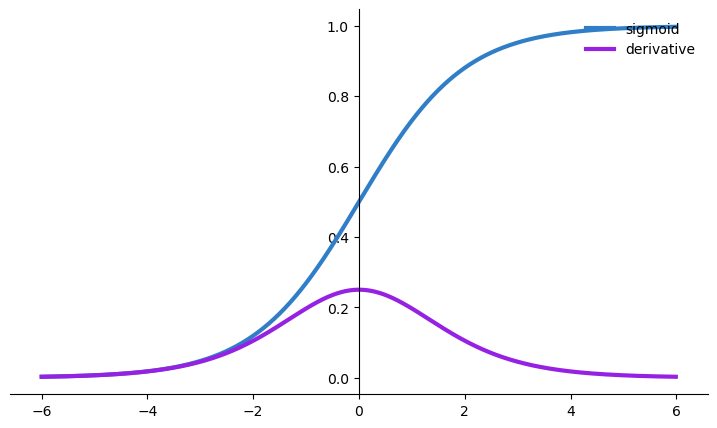

In [20]:
import matplotlib.pyplot as plt
import numpy as np
def sigmoid(x):
    s=1/(1+np.exp(-x))
    ds=s*(1-s)  
    return s,ds
x=np.arange(-6,6,0.01)
sigmoid(x)
fig, ax = plt.subplots(figsize=(9, 5))
ax.spines['left'].set_position('center')
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
ax.plot(x,sigmoid(x)[0], color="#307EC7", linewidth=3, label="sigmoid")
ax.plot(x,sigmoid(x)[1], color="#9621E2", linewidth=3, label="derivative")
ax.legend(loc="upper right", frameon=False)
fig.show()

#### Observations:
- The sigmoid function has values between 0 to 1.
- The output is not zero-centered.
- Sigmoids saturate and kill gradients.
- At the top and bottom level of sigmoid functions, the curve changes slowly, the derivative curve above shows that the slope or gradient it is zero.


#### The derivative tells you a function's sensitivity to change with respect to a change in its input.
A high (absolute) value for the derivative at a certain point means that the function is very steep, and a small change in input may result in a drastic change in its output; conversely, a low absolute value means little change, so not steep at all, with the extreme case that the function is constant when the derivative is zero.

When updating the curve, to know in which direction and how much to change or update the curve depending upon the slope.That is why we use differentiation in almost every part of Machine Learning and Deep Learning.


### b) Tanh Activation Functions
The tanh function is just another possible function that can be used as a non-linear activation function between layers of a neural network. It shares a few things in common with the sigmoid activation function. Unlike a sigmoid function that will map input values between 0 and 1, **the Tanh will map values between -1 and 1**. Similar to the sigmoid function, one of the interesting properties of the tanh function is that the derivative of tanh can be expressed in terms of the function itself.

C:\Users\Leena Ali\AppData\Local\Temp\ipykernel_36584\3088698947.py:19: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


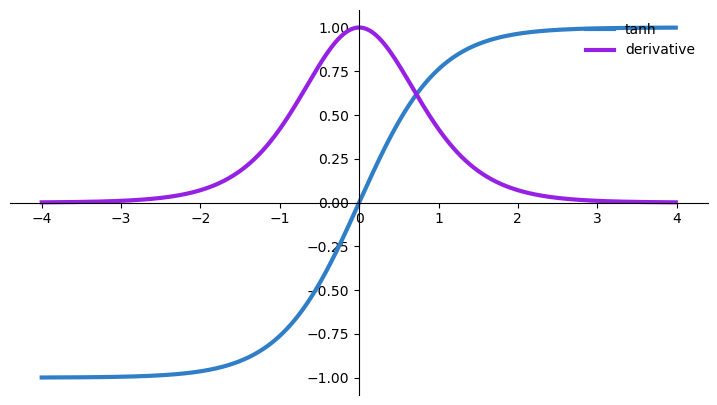

In [21]:
import matplotlib.pyplot as plt
import numpy as np
def tanh(x):
    t=(np.exp(x)-np.exp(-x))/(np.exp(x)+np.exp(-x))
    dt=1-t**2
    return t,dt
z=np.arange(-4,4,0.01)
tanh(z)[0].size,tanh(z)[1].size
fig, ax = plt.subplots(figsize=(9, 5))
ax.spines['left'].set_position('center')
ax.spines['bottom'].set_position('center')
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
ax.plot(z,tanh(z)[0], color="#307EC7", linewidth=3, label="tanh")
ax.plot(z,tanh(z)[1], color="#9621E2", linewidth=3, label="derivative")
ax.legend(loc="upper right", frameon=False)
fig.show()

#### Observations:
Its output is zero-centered because its range is between -1 to 1. i.e. -1 < output < 1.
Optimization is easier in this method hence in practice it is always preferred over the Sigmoid function.

### ReLU 
The formula is deceptively simple: max(0,z). Despite its name, Rectified Linear Units, it’s not linear and **provides the same benefits as Sigmoid but with better performance.**

##### Leaky Relu
Leaky Relu is a variant of ReLU. Instead of being 0 when z<0, a leaky ReLU allows a small, non-zero, constant gradient α (normally, α=0.01). However, the consistency of the benefit across tasks is presently unclear. Leaky ReLUs attempt to fix the “dying ReLU” problem.

##### Parametric Relu
PReLU gives the neurons the ability to choose what slope is best in the negative region. They can become ReLU or leaky ReLU with certain values of α.

#### The ReLU function is a linear function that zeroes out negative values.






In [1]:
import numpy as np
import plotly.express as px


def relu1(a):
    return np.maximum(0, a)


x1 = np.linspace(start=-5, stop=5, num=26)
print("List created using linspace")
print(x1)
x2 = relu1(x1)
print("List after applying ReLU")
print(x2)
px.line(x=x1, y=x2)



List created using linspace
[-5.  -4.6 -4.2 -3.8 -3.4 -3.  -2.6 -2.2 -1.8 -1.4 -1.  -0.6 -0.2  0.2
  0.6  1.   1.4  1.8  2.2  2.6  3.   3.4  3.8  4.2  4.6  5. ]
List after applying ReLU
[0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.2 0.6 1.  1.4 1.8
 2.2 2.6 3.  3.4 3.8 4.2 4.6 5. ]


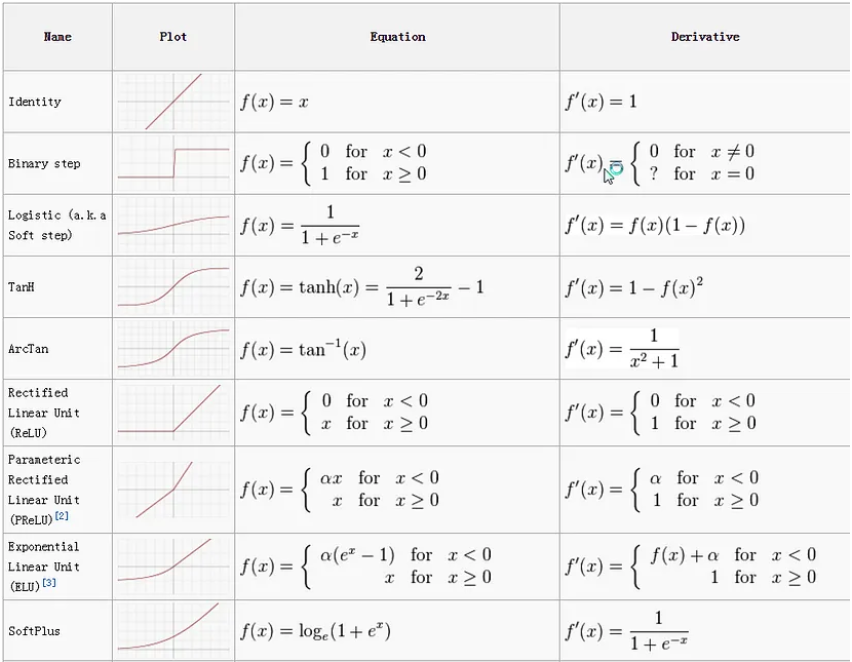

In [7]:
# compile the keras model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Loss Function
Now we need to specify the loss function and the optimizer. It is done using compile function in keras.

A **loss function** is a function that compares the target and predicted output values; measures how well the neural network models the training data. When training, we aim to minimize this loss between the predicted and target outputs.


##### Binary Classification
Binary classification loss function comes into play when solving a problem involving just two classes. For example, when predicting fraud in credit card transactions, a transaction is either fraudulent or not. 

**Cross-entropy measures the performance of a classification model based on the probability and error**, where the more likely (or the bigger the probability) of something is, the lower the cross-entropy.

- **Binary Cross Entropy** - The Binary Cross entropy will calculate the cross-entropy loss between the predicted classes and the true classes.

##### Multiclass classification
Problems involving the prediction of more than one class use different loss functions.

- **Categorical Cross Entropy** - The CategoricalCrossentropy also computes the cross-entropy loss between the true classes and predicted classes.
- **Sparse Categorical Cross Entropy** - If you have two or more classes and  the labels are integers, the SparseCategoricalCrossentropy should be used.

# Optimizer
Optimizer algorithms are optimization method that helps improve a deep learning model’s performance. These optimization algorithms or optimizers widely affect the accuracy and speed training of the deep learning model.

An optimizer is a function or an algorithm that adjusts the attributes of the neural network, such as weights and learning rates. Thus, it helps in reducing the overall loss and improving accuracy. 

**Optimizers are algorithms or methods used to change the attributes of your neural network such as weights and learning rate in order to reduce the losses.**
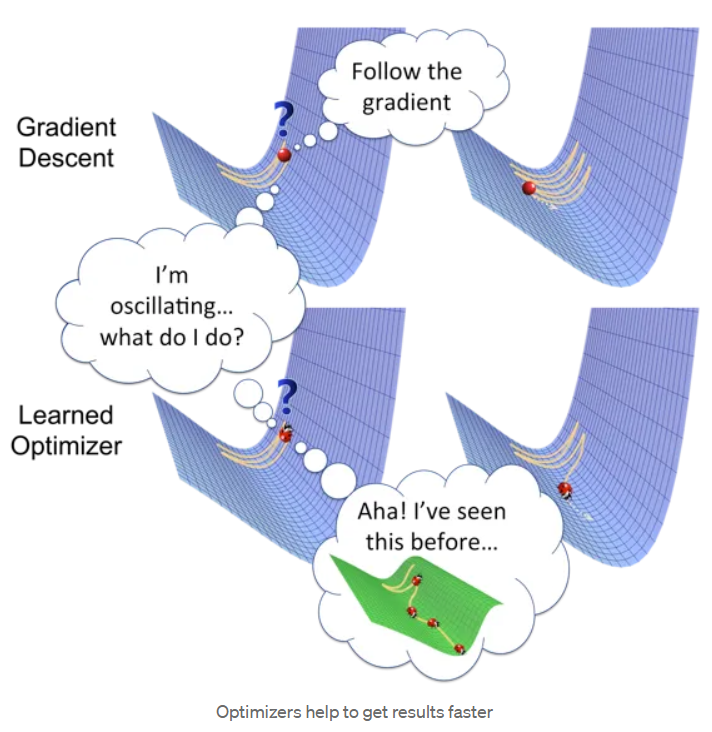

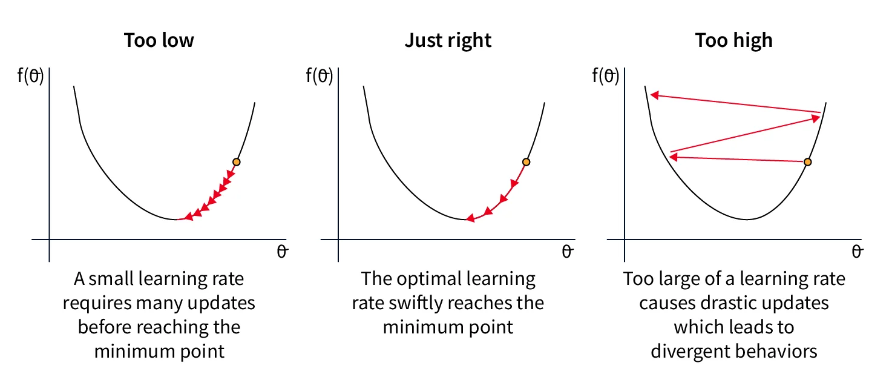

Here are a few common optimizers used in training ANNs:

1. ### Gradient Descent:
 - **Vanilla Gradient Descent**: Adjusts the weights in the opposite direction of the gradient of the loss function with respect to the weights. It has variants like Stochastic Gradient Descent (SGD), which updates the weights based on each individual training example, and Batch Gradient Descent, which updates the weights based on the entire dataset.
2. ### Adaptive Learning Rate Methods:
 - **Adagrad**: Adjusts the learning rate for each parameter based on the historical gradients for that parameter. It decreases the learning rate for frequently occurring parameters and increases it for infrequently occurring ones.
 - **RMSprop**: A variant of Adagrad that uses a moving average of squared gradients to adaptively adjust the learning rates.
 - **Adam (Adaptive Moment Estimation)**: Combines ideas from RMSprop and momentum. It maintains both a decaying average of past gradients and their squared gradients, using them to adaptively adjust learning rates for each parameter.
3. ### Momentum-based Methods:
 - **Momentum**: Helps accelerate gradient descent by adding a fraction of the previous update to the current update, acting like a moving average of gradients. It helps overcome small local minima.
4. ### Second-Order Optimization Methods:
 - **Newton's Method**: Uses the second derivative of the loss function to update the weights. It converges faster than first-order methods but requires computation of the Hessian matrix, making it computationally expensive for large networks.

In [8]:
print(model)

You can train or fit your model on your loaded data by calling the fit() function on the model.

Training occurs over epochs, and each epoch is split into batch

- **Epoch**: One pass through all of the rows in the training dataset
- **Batch**: One or more samples considered by the model within an epoch before weights are updated The batch size is a number of samples processed before the model is updateds.

In [9]:

...
# fit the keras model on the dataset
model.fit(X, y, epochs=150, batch_size=10)

Epoch 1/150
77/77 [==============================] - 2s 4ms/step - loss: 9.5312 - accuracy: 0.6341
Epoch 2/150
77/77 [==============================] - 0s 3ms/step - loss: 1.3483 - accuracy: 0.6354
Epoch 3/150
77/77 [==============================] - 0s 3ms/step - loss: 1.1320 - accuracy: 0.6458
Epoch 4/150
77/77 [==============================] - 0s 3ms/step - loss: 1.0552 - accuracy: 0.6393
Epoch 5/150
77/77 [==============================] - 0s 3ms/step - loss: 0.8506 - accuracy: 0.6445
Epoch 6/150
77/77 [==============================] - 0s 3ms/step - loss: 0.7903 - accuracy: 0.6497
Epoch 7/150
77/77 [==============================] - 0s 3ms/step - loss: 0.7578 - accuracy: 0.6523
Epoch 8/150
77/77 [==============================] - 0s 3ms/step - loss: 0.7315 - accuracy: 0.6758
Epoch 9/150
77/77 [==============================] - 0s 5ms/step - loss: 0.7285 - accuracy: 0.6576
Epoch 10/150
77/77 [==============================] - 0s 5ms/step - loss: 0.7026 - accuracy: 0.6576
Epoch 11/

Epoch 83/150
77/77 [==============================] - 0s 5ms/step - loss: 0.5217 - accuracy: 0.7331
Epoch 84/150
77/77 [==============================] - 0s 4ms/step - loss: 0.5291 - accuracy: 0.7240
Epoch 85/150
77/77 [==============================] - 0s 3ms/step - loss: 0.5251 - accuracy: 0.7487
Epoch 86/150
77/77 [==============================] - 0s 3ms/step - loss: 0.5273 - accuracy: 0.7253
Epoch 87/150
77/77 [==============================] - 0s 3ms/step - loss: 0.5391 - accuracy: 0.7305
Epoch 88/150
77/77 [==============================] - 0s 3ms/step - loss: 0.5230 - accuracy: 0.7435
Epoch 89/150
77/77 [==============================] - 0s 3ms/step - loss: 0.5166 - accuracy: 0.7292
Epoch 90/150
77/77 [==============================] - 0s 3ms/step - loss: 0.5463 - accuracy: 0.7227
Epoch 91/150
77/77 [==============================] - 0s 3ms/step - loss: 0.5295 - accuracy: 0.7344
Epoch 92/150
77/77 [==============================] - 0s 3ms/step - loss: 0.5260 - accuracy: 0.7305


You have trained our neural network on the entire dataset, and you can evaluate the performance of the network on the same dataset.

This will only give you an idea of how well you have modeled the dataset (e.g., train accuracy), but no idea of how well the algorithm might perform on new data. This was done for simplicity, but ideally, you could separate your data into train and test datasets for training and evaluation of your model.

You can evaluate your model on your training dataset using the evaluate() function and pass it the same input and output used to train the model.

This will generate a prediction for each input and output pair and collect scores, including the average loss and any metrics you have configured, such as accuracy.

The evaluate() function will return a list with two values. The first will be the loss of the model on the dataset, and the second will be the accuracy of the model on the dataset. You are only interested in reporting the accuracy so ignore the loss value.

In [10]:

...
# evaluate the keras model
loss, accuracy = model.evaluate(X, y)
print('Accuracy: %.2f' % (accuracy*100))

24/24 [==============================] - 0s 3ms/step - loss: 0.4750 - accuracy: 0.7734
Accuracy: 77.34


In [25]:
# make class predictions with the model
predictions = (model.predict(X) > 0.5).astype(int)
#predictions = (model.predict(X)).astype(int)


24/24 [==============================] - 0s 3ms/step


In [26]:
# summarize the first 5 cases
for i in range(5):
 print('%s => %d (expected %d)' % (X[i].tolist(), predictions[i], y[i]))


[6.0, 148.0, 72.0, 35.0, 0.0, 33.6, 0.627, 50.0] => 1 (expected 1)
[1.0, 85.0, 66.0, 29.0, 0.0, 26.6, 0.351, 31.0] => 0 (expected 0)
[8.0, 183.0, 64.0, 0.0, 0.0, 23.3, 0.672, 32.0] => 1 (expected 1)
[1.0, 89.0, 66.0, 23.0, 94.0, 28.1, 0.167, 21.0] => 0 (expected 0)
[0.0, 137.0, 40.0, 35.0, 168.0, 43.1, 2.288, 33.0] => 1 (expected 1)


In [27]:
Xnew = [[1,85,66,29,0,26,0.3,31]]

ynew = model.predict(Xnew)>0.5
if ynew == 0:
    print('Not Diabetic')
else:
    print('Diabetic')

print(ynew)

1/1 [==============================] - 0s 81ms/step
Not Diabetic
[[False]]
